
# Intelligent Phishing Website Detection Using Machine Learning

# Part 4 – Hyperparameter Tuning & Advanced Model Evaluation

## Objectives

- Hyperparameter Tuning using GridSearchCV
- Hyperparameter Tuning using RandomizedSearchCV
- 5-Fold Cross Validation
- Learning Curve
- Validation Curve
- Feature Importance
- ROC Comparison
- Save Optimized Model


In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    validation_curve
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import *

from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except:
    XGBClassifier=None

import joblib


In [2]:

# Load Dataset

df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

TARGET="label"

X=df.drop(columns=[TARGET])

non_numeric_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [col for col in non_numeric_cols if col in X.columns]
X = X.drop(columns=cols_to_drop)
feature_names = list(X.columns)

y=df[TARGET]


# Split FIRST
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42,
stratify=y
)

# Scale AFTER splitting
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, 'preprocessor.pkl')


['preprocessor.pkl']

## GridSearchCV - Random Forest

In [3]:

rf=RandomForestClassifier(random_state=42)

param_grid={
    'n_estimators':[50,100],
    'max_depth':[10,None],
    'min_samples_split':[2],
    'min_samples_leaf':[1]
}

grid=GridSearchCV(
rf,
param_grid,
cv=3,
n_jobs=-1,
scoring='accuracy'
)

grid.fit(X_train,y_train)

print("Best Parameters")
print(grid.best_params_)

best_rf=grid.best_estimator_


Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


## RandomizedSearchCV

In [4]:

random_search=RandomizedSearchCV(
rf,
param_grid,
n_iter=3,
cv=3,
random_state=42,
n_jobs=-1,
scoring='accuracy'
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)


{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


## Cross Validation

In [5]:

scores=cross_val_score(
best_rf,
X,
y,
cv=3,
scoring='accuracy'
)

print(scores)

print("Average Accuracy:",scores.mean())


[1.         0.99998728 1.        ]
Average Accuracy: 0.9999957590099834


## Learning Curve

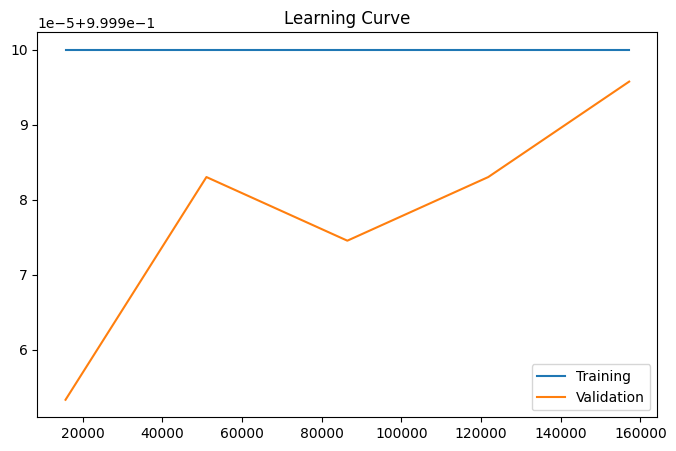

In [6]:

train_sizes,train_scores,test_scores=learning_curve(
best_rf,
X,
y,
cv=3,
n_jobs=-1
)

train_mean=train_scores.mean(axis=1)
test_mean=test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes,train_mean,label="Training")

plt.plot(train_sizes,test_mean,label="Validation")

plt.legend()

plt.title("Learning Curve")

plt.show()


## Validation Curve

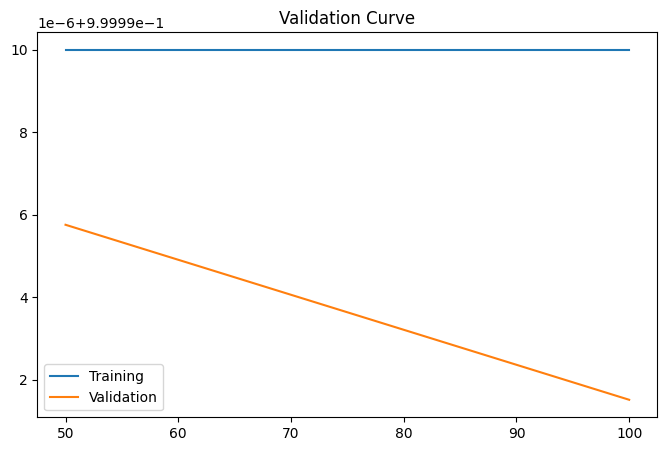

In [7]:

param_range=[50,100]

train_scores,test_scores=validation_curve(
RandomForestClassifier(random_state=42),
X,
y,
param_name="n_estimators",
param_range=param_range,
cv=3
)

plt.figure(figsize=(8,5))

plt.plot(param_range,train_scores.mean(axis=1),label="Training")

plt.plot(param_range,test_scores.mean(axis=1),label="Validation")

plt.legend()

plt.title("Validation Curve")

plt.show()


## Feature Importance

,Feature,Importance
49,NoOfExternalRef,0.186146
22,LineOfCode,0.159527
3,URLSimilarityIndex,0.146485
47,NoOfSelfRef,0.113483
44,NoOfImage,0.095023
46,NoOfJS,0.078101
45,NoOfCSS,0.032542
32,HasDescription,0.032246
21,IsHTTPS,0.023965
23,LargestLineLength,0.018326


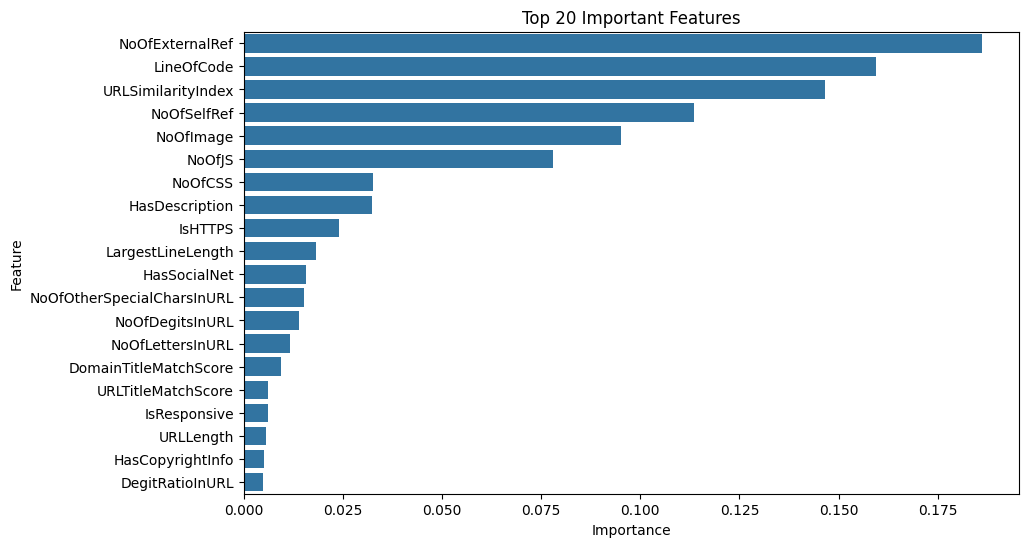

In [8]:

best_rf.fit(X_train,y_train)

importance=pd.DataFrame({
"Feature":feature_names,
"Importance":best_rf.feature_importances_
})

importance=importance.sort_values(
"Importance",
ascending=False
)

display(importance.head(20))

plt.figure(figsize=(10,6))

sns.barplot(
data=importance.head(20),
x="Importance",
y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()


## ROC Curve

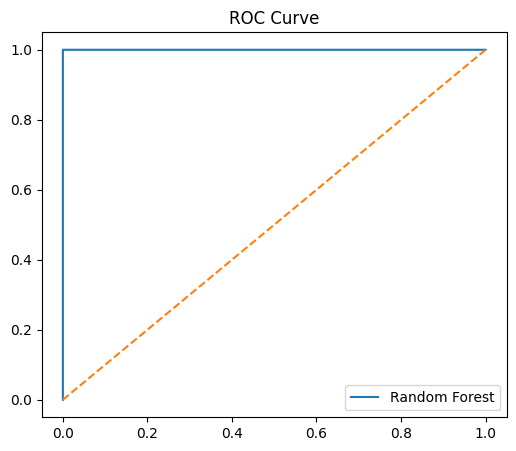

ROC AUC: 1.0


In [9]:

prob=best_rf.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.title("ROC Curve")

plt.show()

print("ROC AUC:",roc_auc_score(y_test,prob))


## Final Evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



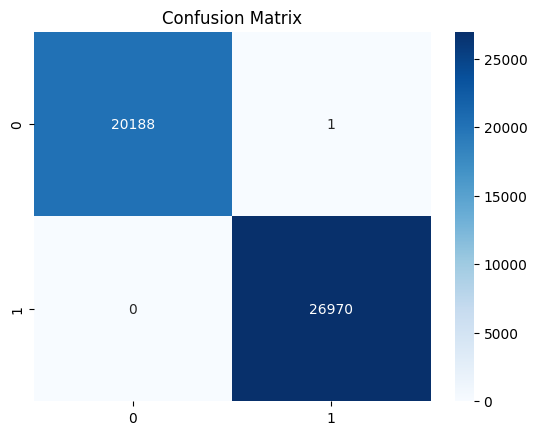

In [10]:

pred=best_rf.predict(X_test)

print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()


In [11]:

joblib.dump(best_rf,"optimized_phishing_model.pkl")

print("Optimized Model Saved")


Optimized Model Saved



# Summary

This notebook performed:

- GridSearchCV
- RandomizedSearchCV
- 5-Fold Cross Validation
- Learning Curve
- Validation Curve
- Feature Importance
- ROC Curve
- Final Evaluation
- Saved Optimized Model

The next notebook (Part 5) will include:

- SHAP Explainable AI
- Risk Score (0-100)
- Human-readable Reasons
- Deployment-ready Prediction Pipeline
- Real Website Testing
